Trying to understand unique characteristics of the person sitting right and left. We will start from the frames where 2 people are detected (because they are almost all with person1 and person2) and from there we will "learn" unique characteristics of each

In [1]:
import pandas as pd
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
import math
from scipy.spatial.distance import cdist

In [2]:
# Select candidates 

person1 = 'Martins'
person2 = 'Gouveia_Melo'

In [3]:
# Load visual pkl for debate with person 1 and person 2 OR all debates with person 1 OR all debates
pklfiles = []

if not person1:
    for file in os.listdir('Project_Features'):
        if file.endswith('visual.pkl'):
            pklfiles.append(file)
elif not person2:
    for file in os.listdir('Project_Features'):
        if file.endswith('visual.pkl') and person1 in file:
            pklfiles.append(file)
else:
    for file in os.listdir('Project_Features'):
        if file.endswith('visual.pkl') and person1 in file and person2 in file:
            pklfiles.append(file)


data = []

for video in pklfiles:
    print(f"Loading: {video}")
    df = pd.read_pickle(os.path.join('Project_Features', video))
    data.append(df)

data = pd.concat(data, ignore_index=True)

data['Video_Name'] = data['Frame'].str.extract(r'Frames/([^/]+)/')
data['Frame_Number'] = data['Frame'].str.extract(r'frame_(\d+)\.jpg').astype(int)
data = data.sort_values(by=['Video_Name', 'Frame_Number']).reset_index(drop=True)


Loading: Martins_vs_Gouveia_Melo_November_23_visual.pkl


In [9]:
master_data = []

for index, row in data.iterrows():
    frame_id = row['Frame']
    frame_number = row['Frame_Number']
    faces = row['Fer']
    poses = row['Poses'] 
    
    if isinstance(faces, list) and len(faces) > 0 and len(faces)<=3:
        valid_faces = [f for f in faces if isinstance(f, dict) and 'bbox' in f]
        people_count = len(valid_faces)
        
        for i, face in enumerate(valid_faces):
            # 1. Face Coordinates
            f_box = face['bbox'] # [x1, y1, x2, y2]
            f_width = f_box[2] - f_box[0]
            f_height = f_box[3] - f_box[1]
            
            f_x_center = f_box[0] + (f_width / 2)
            f_y_center = f_box[1] + (f_height / 2) 
            face_area = f_width * f_height

            ratio_face = f_width/f_height
            
            top_emotion = face.get('top_emotion')
            probability = face['probabilities'].get(top_emotion) if top_emotion and 'probabilities' in face else None
            landmarks = face.get('landmarks')
            
            # MATCHING THE FACE TO TE BODY -- this way our df will have 1 person per row
            matched_body_bbox = None
            matched_pose_keypoints = None
            ratio_shoulder_face =None
            ratio_nose_shoulder_w =None
            ratio_eyes_face =None

            if isinstance(poses, list):
                for person in poses:
                    if isinstance(person, dict)and len(person) > 0:
                        b_box = person['bbox'] 
                        
                        # is the center of the face inside this body's bounding box?
                        #note that b_box[3] > bbox[1] because y axis goes down
                        if (b_box[0] <= f_x_center <= b_box[2]) and (b_box[1] <= f_y_center <= b_box[3]):
                            matched_body_bbox = b_box
                            #matrix 17x3 - assuming (x,y, prob)
                            matched_pose_keypoints = person.get('pose') 

                            #-----RATIOS--------
                            #ratio shoulder width to face
                            l_shoulder = matched_pose_keypoints[5][0:2]
                            r_shoulder = matched_pose_keypoints[6][0:2]
                            shoulder_width = abs(r_shoulder[0] - l_shoulder[0])
                            ratio_shoulder_face = shoulder_width/f_width

                            #distance from nose to midpoint of shoulders/shoulder_width
                            m_shoulder_y = (l_shoulder[1]+r_shoulder[1])/2
                            nose =matched_pose_keypoints[0][0:2]
                            dist_nose_shoulder = m_shoulder_y-nose[1]
                            ratio_nose_shoulder_w = dist_nose_shoulder/shoulder_width

                            #distance between eyes/ face_width
                            l_eye = matched_pose_keypoints[1][0:2]
                            r_eye = matched_pose_keypoints[2][0:2]
                            dist_eyes = abs(r_eye[0]-l_eye[0])
                            ratio_eyes_face = dist_eyes/f_width


                            break 
            
            # 3. Append everything safely
            master_data.append({
                'Frame': frame_id,
                'Frame_Number': frame_number,
                'People_Count': people_count,
                'Person_Index': i,
                'Face_X_Center': f_x_center,
                'Face_Area': face_area,
                'Face_BBox': f_box,
                'Body_BBox': matched_body_bbox,         
                'Top_Emotion': top_emotion,
                'Emotion_Prob': probability,
                'Landmarks': landmarks,
                'Pose_Keypoints': matched_pose_keypoints, 
                'Ratio_Face': ratio_face,
                'Ratio_Shoulder_Face': ratio_shoulder_face,
                'Ratio_Nose_Shoulder': ratio_nose_shoulder_w,
                'Ratio_Eyes_Face': ratio_eyes_face
            })
            
    else:
        # Handle empty frames
        master_data.append({
            'Frame': frame_id, 'Frame_Number': frame_number, 'People_Count': 0, 'Person_Index': None,
            'Face_X_Center': None, 'Face_Area': None, 'Face_BBox': None,
            'Body_BBox': None, 'Top_Emotion': None, 'Emotion_Prob': None,
            'Landmarks': None, 'Pose_Keypoints': None, 'Ratio_Face': None,
            'Ratio_Shoulder_Face': None, 'Ratio_Nose_Shoulder': None, 'Ratio_Eyes_Face':None
        })

df_people = pd.DataFrame(master_data)
print(f"Important data (df shape): {df_people.shape}")

Important data (df shape): (3261, 16)


## 2 people frames

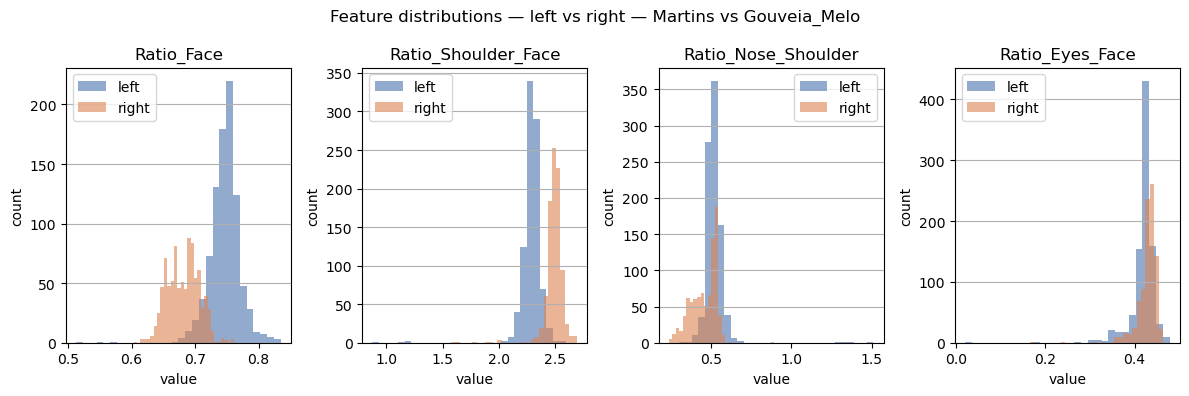

In [10]:
# filter the df_people (we want only 2-person frames)
df_two_people = df_people[df_people['People_Count'] == 2].copy()

#map data frame row (one person) to left or right
index_to_side = {}
# label left vs right based on x center
for frame_num, people in df_two_people.groupby('Frame_Number'):
    sorted_index = people.sort_values('Face_X_Center').index #sorts df index by the x center
    index_to_side[sorted_index[0]]= 'left'
    index_to_side[sorted_index[1]]='right'

df_two_people['side'] = df_two_people.index.map(index_to_side)

# plot distributions for each ratio
features = ['Ratio_Face', 'Ratio_Shoulder_Face', 'Ratio_Nose_Shoulder', 'Ratio_Eyes_Face']

fig, axes = plt.subplots(1,4,figsize=(12,4))

for i in range(len(features)):
    ratio = features[i]
    ax = axes[i]

    mask_left = df_two_people['side']== 'left'
    mask_right = df_two_people['side'] == 'right'
    left_vals = df_two_people[mask_left][ratio].dropna()
    right_vals = df_two_people[mask_right][ratio].dropna()

    ax.hist(left_vals,  bins=30, alpha=0.6, color='#4C72B0', label='left')
    ax.hist(right_vals, bins=30, alpha=0.6, color='#DD8452', label='right')
    ax.set_title(ratio)
    ax.set_xlabel('value')
    ax.set_ylabel('count')
    ax.grid(True, axis='y')
    ax.legend()

plt.suptitle(f'Feature distributions — left vs right — {person1} vs {person2}')
plt.tight_layout()
plt.show()

The best ratios seem to be the Ratio_Face and Ratio_Shoulder_Face. Usually it seems that al least one of the ratios visually separates the left and right candidate. But there are problematic cases. Gouveia_Melo and Cotrim are physically similar thus none of the ratios seemed to be good enought to distinguish them

In [6]:
mask_left = df_two_people['side']== 'left'
mask_right = df_two_people['side'] == 'right'

#face ratio
mean_left_ratio_face = df_two_people[mask_left]['Ratio_Face'].mean()
mean_right_ratio_face = df_two_people[mask_right]['Ratio_Face'].mean()
thr_ratio_face = (mean_left_ratio_face+mean_right_ratio_face)/2

print(f'Threshold of Ratio_Face: {thr_ratio_face}')

#shouder to face ratio
mean_left_shoulder_face = df_two_people[mask_left]['Ratio_Shoulder_Face'].mean()
mean_right_shoulder_face = df_two_people[mask_right]['Ratio_Shoulder_Face'].mean()
thr_shoulder_face = (mean_left_shoulder_face+mean_right_shoulder_face)/2

print(f'Threshold of Ratio_Shoulder_Face: {thr_shoulder_face}')

#finding out who (left or right) has a smaller Face_Ratio and Shoulder_Face_RAtio
if mean_left_ratio_face < thr_ratio_face:
    print('person left has a smaller Face_Ratio')
else:
    print('person right has a smaller Face_Ratio')

if mean_left_shoulder_face < thr_shoulder_face:
    print('person left has a smaller Shoulder_Face_Ratio')
else:
    print('person right has smaller Shoulder_Face_Ratio' )

Threshold of Ratio_Face: 0.7140782114133968
Threshold of Ratio_Shoulder_Face: 2.3869391522087673
person right has a smaller Face_Ratio
person left has a smaller Shoulder_Face_Ratio


## 3 people frames

In [7]:
df_3_people = df_people[df_people['People_Count'] == 3].copy()

# label left, host, right by x_center position within each frame
index_to_position = {}

for frame_num, group in df_3_people.groupby('Frame_Number'):
    sorted_indices = group.sort_values('Face_X_Center').index
    
    index_to_position[sorted_indices[0]] = 'person_left'
    index_to_position[sorted_indices[1]] = 'host'
    index_to_position[sorted_indices[2]] = 'person_right'

df_3_people['side'] = df_3_people.index.map(index_to_position)

print(f"3-person frames: {df_3_people['Frame_Number'].nunique()}")
print(df_3_people['side'].value_counts())

3-person frames: 156
side
person_right    156
person_left     156
host            156
Name: count, dtype: int64


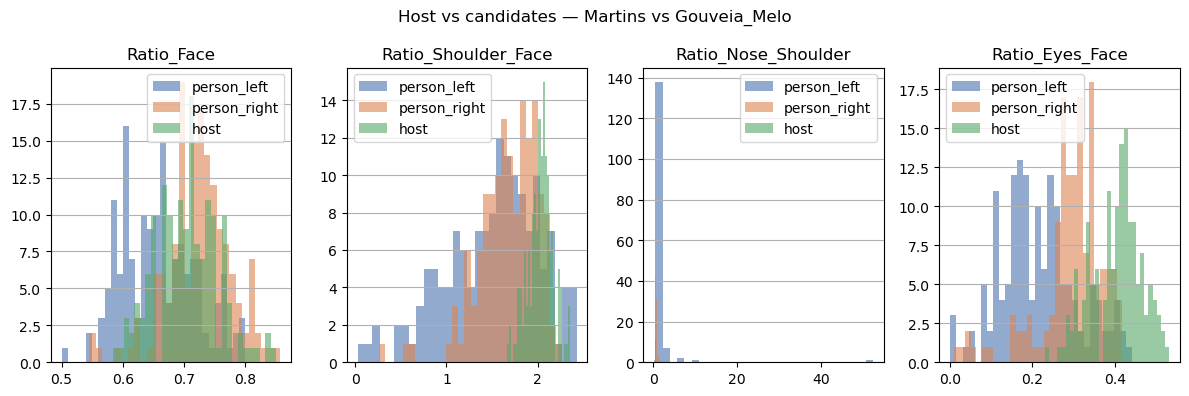

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(12, 4))

features = ['Ratio_Face', 'Ratio_Shoulder_Face', 'Ratio_Nose_Shoulder', 'Ratio_Eyes_Face']

for i in range(len(features)):
    feat = features[i]
    ax = axes[i]
    
    # candidates from 2-person frames
    mask_left = df_two_people['side']== 'left'
    mask_right = df_two_people['side'] == 'right'
    
    left_vals  = df_3_people[df_3_people['side'] == 'person_left'][feat].dropna()
    right_vals = df_3_people[df_3_people['side'] == 'person_right'][feat].dropna()
    host_vals  = df_3_people[df_3_people['side'] == 'host'][feat].dropna()
    
    ax.hist(left_vals,  bins=30, alpha=0.6, color='#4C72B0', label='person_left')
    ax.hist(right_vals, bins=30, alpha=0.6, color='#DD8452', label='person_right')
    ax.hist(host_vals,  bins=30, alpha=0.6, color='#55A868', label='host')
    ax.set_title(feat)
    ax.legend()
    ax.grid(True, axis='y')

plt.suptitle(f'Host vs candidates — {person1} vs {person2}')
plt.tight_layout()
plt.show()

We already suspected that we should not relly much on 3 person frames, because they are very few and the bounding boxes are very small. Given that, and the overlapping of the distriuions makes us conclude that we dont have enough host information to conclude their specific features.

This leads to the problem: What should we do with 1 person frames if we cannot ditinguish the host (do not have enough data)?

- option A - just assume misclassification and classify 1-person frames as 'right' or 'left'
- option B - use ratios and uncertainty zone. if the threshold is clearly on one side, assume uncertaint

## Labelling (still with uncertainty)

In [11]:
print(f"mean Ratio_Face      — left: {mean_left_ratio_face:.3f}  right: {mean_right_ratio_face:.3f}  threshold: {thr_ratio_face:.3f}")
print(f"mean Ratio_Shoulder  — left: {mean_left_shoulder_face:.3f}  right: {mean_right_shoulder_face:.3f}  threshold: {thr_shoulder_face:.3f}")

df_people['label'] = 'unlabeled'

#3 people frame
for frame_num, group in df_3_people.groupby('Frame_Number'):
    sorted_indices = group.sort_values('Face_X_Center').index

    df_people.loc[sorted_indices[0], 'label'] = 'person_left'
    df_people.loc[sorted_indices[1], 'label'] = 'host'
    df_people.loc[sorted_indices[2], 'label'] = 'person_right'

#2 people frame
for frame_num, group in df_two_people.groupby('Frame_Number'):
    sorted_indices = group.sort_values('Face_X_Center').index
    df_people.loc[sorted_indices[0], 'label'] = 'person_left'
    df_people.loc[sorted_indices[1], 'label'] = 'person_right'


#1 people frame
df_1_person = df_people[df_people['People_Count'] == 1].copy()

for idx, row in df_1_person.iterrows():
    ratio_face     = row['Ratio_Face']
    ratio_shoulder = row['Ratio_Shoulder_Face']
    
    # missing keypoints
    if pd.isna(ratio_face) or pd.isna(ratio_shoulder):
        df_people.loc[idx, 'label'] = 'uncertain'
        continue
    
    face_vote     = 'person_left' if ratio_face > 0.714 else 'person_right'
    shoulder_vote = 'person_left' if ratio_shoulder < 2.387 else 'person_right'
    
    if face_vote == shoulder_vote:
        df_people.loc[idx, 'label'] = face_vote
    else:
        df_people.loc[idx, 'label'] = 'uncertain'

# --- 0 PEOPLE FRAMES ---
df_people.loc[df_people['People_Count'] == 0, 'label'] = 'no_people'

print(df_people['label'].value_counts())


mean Ratio_Face      — left: 0.747  right: 0.681  threshold: 0.714
mean Ratio_Shoulder  — left: 2.287  right: 2.487  threshold: 2.387
label
person_right    1516
person_left     1426
uncertain        161
host             156
no_people          2
Name: count, dtype: int64


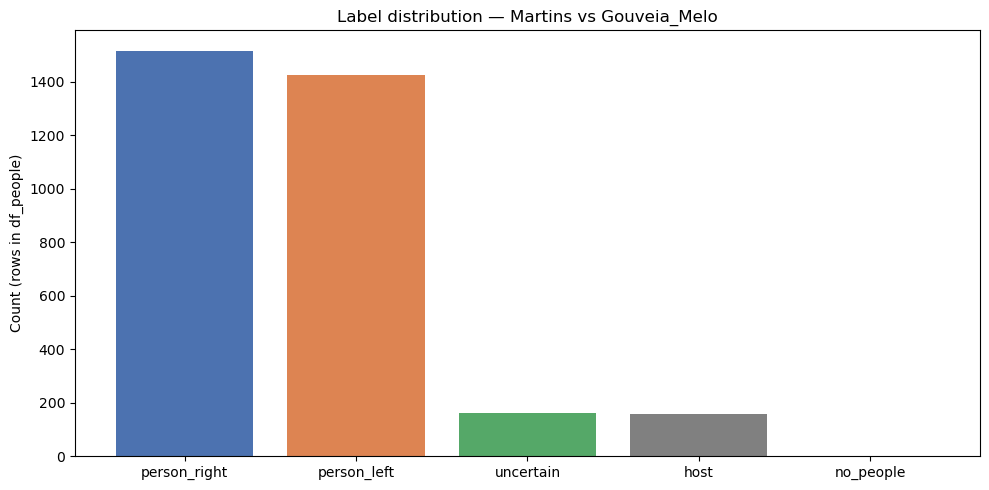

/var/folders/06/d17c585n3mv1xg86jk2xpj340000gn/T/ipykernel_61314/3291560356.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_frame_summary = df_people.groupby('Frame_Number').apply(summarize_frame).reset_index()


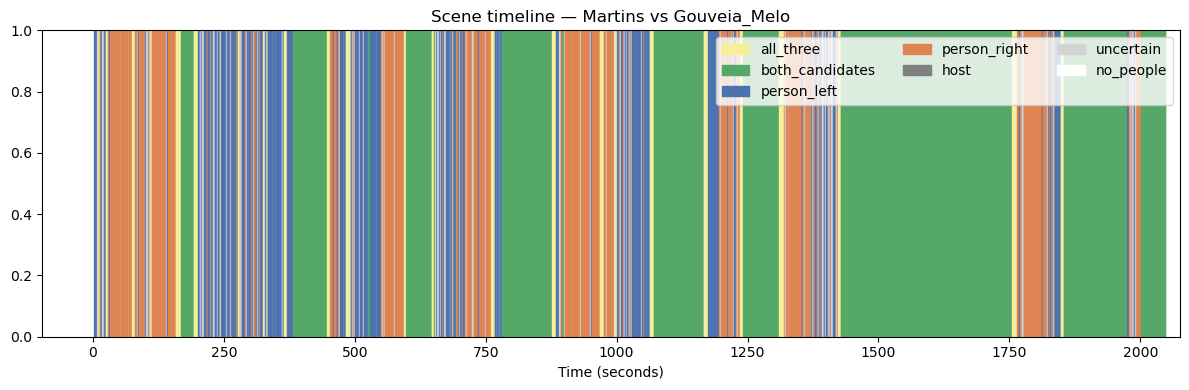

In [12]:
# --- Bar chart ---
label_counts = df_people['label'].value_counts()

plt.figure(figsize=(10, 5))
colors = ['#4C72B0', '#DD8452', '#55A868', 'gray', 'lightgray', 'white']
plt.bar(label_counts.index, label_counts.values, color=colors)
plt.ylabel('Count (rows in df_people)')
plt.title(f'Label distribution — {person1} vs {person2}')
plt.tight_layout()
plt.show()

# --- Timeline ---
# one row per frame, pick the most informative label
# (if frame has person_left and person_right, we want to show 'both')
color_map = {
    'person_left':  '#4C72B0',
    'person_right': '#DD8452',
    'host':         '#55A868',
    'uncertain':    'lightgray',
    'no_people':    'white'
}

def summarize_frame(group):
    labels = set(group['label'].values)
    if 'person_left' in labels and 'person_right' in labels and 'host' in labels:
        return 'all_three'
    elif 'person_left' in labels and 'person_right' in labels:
        return 'both_candidates'
    elif len(labels) == 1:
        return list(labels)[0]
    return 'uncertain'

df_frame_summary = df_people.groupby('Frame_Number').apply(summarize_frame).reset_index()
df_frame_summary.columns = ['Frame_Number', 'frame_label']

color_map_timeline = {
    'all_three':       "#F4EF98",
    'both_candidates': '#55A868',
    'person_left':     '#4C72B0',
    'person_right':    '#DD8452',
    'host':            'gray',
    'uncertain':       'lightgray',
    'no_people':       'white'
}

plt.figure(figsize=(12, 4))
for _, row in df_frame_summary.iterrows():
    color = color_map_timeline.get(row['frame_label'], 'white')
    plt.axvline(x=row['Frame_Number'], color=color, linewidth=1)

from matplotlib.patches import Patch
legend = [Patch(color=c, label=l) for l, c in color_map_timeline.items()]
plt.legend(handles=legend, loc='upper right', ncol=3)
plt.xlabel('Time (seconds)')
plt.title(f'Scene timeline — {person1} vs {person2}')
plt.tight_layout()
plt.show()